In [1]:
# Installation cell
# Run this cell only at the beginning of a fresh Kaggle/Colab session.
INSTALL_PACKAGES = True

if INSTALL_PACKAGES:
    !pip uninstall -y transformers tokenizers accelerate huggingface_hub
    !pip install -q --no-cache-dir \
        "git+https://github.com/huggingface/transformers.git" \
        "huggingface_hub>=0.36.2" \
        "accelerate" \
        "safetensors" \
        "sentencepiece" \
        "protobuf" \
        "datasets" \
        "seaborn" \
        "tqdm"

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: accelerate 1.12.0
Uninstalling accelerate-1.12.0:
  Successfully uninstalled accelerate-1.12.0
Found existing installation: huggingface_hub 1.4.1
Uninstalling huggingface_hub-1.4.1:
  Successfully uninstalled huggingface_hub-1.4.1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 366.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 170.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 189.1 MB/s eta 0:00:00


In [2]:
# Imports and global configuration
import os
import re
import gc
import json
import time
import random
import shutil
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from itertools import product
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from tqdm.auto import tqdm
from functools import lru_cache
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

INFERENCE_MODE = "generate"
FAST_DEBUG = False
DEBUG_VALID_SIZE = 300
BATCH_SIZE = 8
MAX_INPUT_TOKENS = 1600

LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
VALID_LABELS = LABELS

ID_TO_LABEL = {
    0: "Ambivalent",
    1: "Clear Reply",
    2: "Clear Non-Reply",
}

# Required comparison models
MODEL_NAMES_FULL = [
    "Qwen/Qwen3.5-0.8B",
    "Qwen/Qwen3.5-2B",
    "Qwen/Qwen3.5-4B",
]

# Smaller/faster setup for debugging
MODEL_NAMES_DEBUG = [
    "Qwen/Qwen3.5-0.8B",
]

MODEL_NAMES = MODEL_NAMES_DEBUG if FAST_DEBUG else MODEL_NAMES_FULL

# Required prompting strategies
PROMPT_STRATEGIES = [
    "zero_shot",
    "few_shot",
    "cot",
]

# Output directory
if Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("/kaggle/working")
elif Path("/content").exists():
    OUTPUT_DIR = Path("/content")
else:
    OUTPUT_DIR = Path(".")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTPUT_DIR)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Output directory: /kaggle/working
CUDA available: True
GPU: Tesla T4


## 1. Data loading and preprocessing

In [3]:
# Data loading
def find_file_by_name(root: str, filename: str) -> Optional[Path]:
    root = Path(root)
    if not root.exists():
        return None
    matches = list(root.rglob(filename))
    return matches[0] if matches else None


def standardize_columns(df: pd.DataFrame, has_label: bool = True) -> pd.DataFrame:

    df = df.copy()
    lower_to_col = {str(c).lower(): c for c in df.columns}

    def pick_column(candidates: List[str]) -> Optional[str]:
        for cand in candidates:
            if cand in lower_to_col:
                return lower_to_col[cand]
        return None

    question_col = pick_column(["interview_question", "question", "q"])
    answer_col = pick_column(["interview_answer", "answer", "response", "a"])
    id_col = pick_column(["id", "index", "example_id"])

    if question_col is None:
        raise ValueError(f"No question column. Columns={list(df.columns)}")
    if answer_col is None:
        raise ValueError(f"No answer column. Columns={list(df.columns)}")

    out = pd.DataFrame()
    out["id"] = df[id_col].values if id_col is not None else np.arange(len(df))
    out["question"] = df[question_col].fillna("").astype(str)
    out["answer"] = df[answer_col].fillna("").astype(str)

    if has_label:
        label_col = pick_column(["label", "clarity_label", "class", "category", "clarity", "target"])
        if label_col is None:
            raise ValueError(f"No label column. Columns={list(df.columns)}")

        out["label"] = df[label_col].astype(str).str.strip()
        unique_labels = set(out["label"].unique())

        if unique_labels.issubset({"0", "1", "2"}):
            out["label"] = out["label"].astype(int).map(ID_TO_LABEL)

    return out


sample_submission_path = find_file_by_name("/kaggle/input", "sample_submission.csv")
train_path = find_file_by_name("/kaggle/input", "train.csv")
test_path = find_file_by_name("/kaggle/input", "test.csv")

if train_path is not None and test_path is not None:
    print("Loading Kaggle files")
    print("train:", train_path)
    print("test:", test_path)
    print("sample submission:", sample_submission_path)

    train_df = standardize_columns(pd.read_csv(train_path), has_label=True)
    test_df = standardize_columns(pd.read_csv(test_path), has_label=False)
    sample_submission = pd.read_csv(sample_submission_path) if sample_submission_path else None
else:
    print("Kaggle files not found. Loading Hugging Face dataset: ailsntua/QEvasion")
    ds_train = load_dataset("ailsntua/QEvasion", split="train")
    ds_test = load_dataset("ailsntua/QEvasion", split="test")

    train_df = standardize_columns(ds_train.to_pandas(), has_label=True)
    test_raw = ds_test.to_pandas()
    has_test_label = any(str(c).lower() in ["label", "clarity_label"] for c in test_raw.columns)
    test_df = standardize_columns(test_raw, has_label=has_test_label)
    if "label" in test_df.columns:
        test_df = test_df.drop(columns=["label"])
    sample_submission = None

# Basic validation
assert set(train_df["label"].unique()).issubset(set(LABELS)), train_df["label"].unique()

print("train:", train_df.shape, "test:", test_df.shape)
display(train_df.head())
display(test_df.head())
display(train_df["label"].value_counts())

Kaggle files not found. Loading Hugging Face dataset: ailsntua/QEvasion


README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

train: (3448, 4) test: (308, 3)


,id,question,answer,label
0,0,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",Clear Reply
1,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",Ambivalent
2,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",Ambivalent
3,3,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",Ambivalent
4,4,"Q. I can imagine. It is evening, I'd like to r...","Well, I hope I get to see Mr. Xi sooner than l...",Clear Reply


,id,question,answer
0,0,"Q. What about the redline, sir?","Well, the world has made it clear that these t..."
1,1,Q. Will you invite them to the White House to ...,I think that anytime and anyplace that they ar...
2,2,"Q. Harsh. Mr. President, Japan has dropped the...",I think that the purpose of the U.N. Security ...
3,3,Q. The Lebanese Prime Minister is demanding a ...,I'll let Condi talk about the details of what ...
4,4,"Q. Thank you, Mr. President. Back on Iraq, a g...","No, I don't consider it a credible report; nei..."


label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64

In [4]:
# Train/validation split
prompt_pool, valid_part = train_test_split(train_df, test_size=0.20, random_state=SEED, stratify=train_df["label"])

prompt_pool = prompt_pool.reset_index(drop=True)
valid_part = valid_part.reset_index(drop=True)

if FAST_DEBUG:
    debug_n = min(DEBUG_VALID_SIZE, len(valid_part))

    if debug_n < len(valid_part):
        _, valid_part = train_test_split(valid_part,test_size=debug_n,random_state=SEED,stratify=valid_part["label"])
    else:
        valid_part = valid_part.sample(frac=1.0, random_state=SEED)

valid_part = valid_part.reset_index(drop=True)
y_valid = valid_part["label"].tolist()

print("Validation used:", valid_part.shape)
display(valid_part["label"].value_counts())

print("Prompt/example pool:", prompt_pool.shape)
print("Validation:", valid_part.shape)
display(valid_part["label"].value_counts())

y_valid = valid_part["label"].tolist()

Validation used: (690, 4)


label
Ambivalent         408
Clear Reply        211
Clear Non-Reply     71
Name: count, dtype: int64

Prompt/example pool: (2758, 4)
Validation: (690, 4)


label
Ambivalent         408
Clear Reply        211
Clear Non-Reply     71
Name: count, dtype: int64

## 2. Prompt design

In [5]:
# Prompt definitions
BASE_SYSTEM_PROMPT = """
You are a strict but balanced classifier for political interview question-answer pairs.

Your task is to classify the answer into exactly one of these three labels:

1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Definitions:

Clear Reply:
The answer directly, specifically, and substantially answers the exact question that was asked.

Ambivalent:
The answer is related to the question but only partially answers it. Use this label when the answer is vague, incomplete, indirect, mixed, over-general, or does not fully commit to a clear answer.

Clear Non-Reply:
The answer does not answer the question at all. Use this label only when the answer clearly changes topic, refuses to answer, gives an unrelated statement, or is almost entirely evasive.

Important rules:
- Do NOT classify an answer as Clear Reply just because it mentions the same topic as the question.
- If the answer is related to the question but incomplete, vague, indirect, or only partially answers it, choose Ambivalent.
- Choose Clear Non-Reply only when the answer mostly or completely avoids the question.
- When unsure between Ambivalent and Clear Non-Reply, choose Ambivalent.
- Output only one of the three valid labels.
- Do not explain your answer.
""".strip()


def make_few_shot_examples(train_df, n_per_class=2, seed=SEED):
    examples = []

    for label in VALID_LABELS:
        part = train_df[train_df["label"] == label].sample(
            n=n_per_class,
            random_state=seed,
            replace=False,
        )
        examples.extend(part[["question", "answer", "label"]].to_dict("records"))

    random.Random(seed).shuffle(examples)
    return examples

FEW_SHOT_EXAMPLES = make_few_shot_examples(prompt_pool, n_per_class=2, seed=SEED)

print("Few-shot label distribution:")
display(pd.Series([ex["label"] for ex in FEW_SHOT_EXAMPLES]).value_counts())

print("Few-shot examples:")
for ex in FEW_SHOT_EXAMPLES:
    print("=" * 80)
    print("Label:", ex["label"])
    print("Question:", ex["question"][:300])
    print("Answer:", ex["answer"][:300])

Few-shot label distribution:


Ambivalent         2
Clear Reply        2
Clear Non-Reply    2
Name: count, dtype: int64

Few-shot examples:
Label: Ambivalent
Question: Q. Good morning, Your Excellencies. My question is to President Bush. Looking at Africa from afar, things might look bleak, but all may not be lost yet. A new Africa is emerging. But in your candid view, what do you think Africa must do, and what kind of leadership do you expect to see in Africa? An
Answer: Thanks. I actually went to Africa on the first lap of my Presidency too. This is my second trip to the continent of Africa, and I've come to remind our fellow citizens that it is in our interest to help countries deal with curable diseases like malaria and difficult diseases like HIV/ AIDS; that it'
Label: Clear Reply
Question: Q. Thank you. Mr. President, you tweeted this morning that it's U.S. foolishness, stupidity, and the Mueller probe that is responsible for the decline in U.S. relations with Russia. Do you hold Russia at all accountable for anything in particular? And if so, what would you consider them—that they ar
Answer: Yes, 

In [6]:
# Prompt builders
def build_scoring_prompt(row, strategy: str = "zero_shot", few_shot_examples: Optional[List[Dict]] = None) -> str:
    """Prompt used by constrained label scoring."""
    q = str(row["question"]).strip()
    a = str(row["answer"]).strip()

    if strategy == "zero_shot":
        return f"""
{BASE_SYSTEM_PROMPT}

Question:
{q}

Answer:
{a}

Label:
""".strip()

    if strategy == "few_shot":
        examples_text = ""
        for ex in few_shot_examples or []:
            examples_text += f"""
Question:
{ex["question"]}

Answer:
{ex["answer"]}

Label:
{ex["label"]}

---
""".strip() + "\n\n"

        return f"""
{BASE_SYSTEM_PROMPT}

Examples:

{examples_text}
Now classify the new example.

Question:
{q}

Answer:
{a}

Label:
""".strip()

    if strategy == "cot":
        # We do not generate chain-of-thought. We use a reasoning-oriented instruction
        # but still score only the final label candidates.
        return f"""
{BASE_SYSTEM_PROMPT}

Before choosing the label, consider:
1. What exactly is the question asking?
2. Does the answer directly answer that exact question?
3. Is the answer only partially related, vague, or evasive?

Question:
{q}

Answer:
{a}

Final label:
""".strip()

    raise ValueError(f"Unknown strategy: {strategy}")

def build_user_prompt(row, strategy="zero_shot", few_shot_examples=None):
    q = str(row["question"]).strip()
    a = str(row["answer"]).strip()

    if strategy == "zero_shot":
        return f"""
Classify the following political question-answer pair.

Question:
{q}

Answer:
{a}

Valid labels:
Clear Reply
Ambivalent
Clear Non-Reply

Decision guide:
- Choose Clear Reply only if the answer directly answers the exact question.
- Choose Ambivalent if the answer is relevant but partial, vague, indirect, incomplete, or mixed.
- Choose Clear Non-Reply only if the answer mostly or completely avoids the question.
- If unsure between Ambivalent and Clear Non-Reply, choose Ambivalent.

Final label:
""".strip()

    if strategy == "few_shot":
        examples_text = ""

        for ex in few_shot_examples:
            examples_text += f"""
Question:
{ex["question"]}

Answer:
{ex["answer"]}

Final label:
{ex["label"]}

---
""".strip() + "\n\n"

        return f"""
Here are labeled examples of the task.

{examples_text}

Now classify the new example.

Question:
{q}

Answer:
{a}

Valid labels:
Clear Reply
Ambivalent
Clear Non-Reply

Remember:
- Clear Reply requires a direct answer to the exact question.
- Ambivalent is for partial, vague, indirect, or incomplete answers.
- Clear Non-Reply is for evasive or irrelevant answers.

Final label:
""".strip()

    if strategy == "cot":
        return f"""
Classify the following political question-answer pair.

Question:
{q}

Answer:
{a}

Before deciding, check:
1. What exactly is the question asking?
2. Does the answer directly and specifically answer that exact question?
3. Is the answer only partially relevant, vague, indirect, or incomplete?
4. Does the answer avoid the question?

Choose exactly one label:
Clear Reply
Ambivalent
Clear Non-Reply

Return only this format:
Final label: <label>
""".strip()

    raise ValueError(f"Unknown strategy: {strategy}")

def build_chat_prompt(tokenizer, system_prompt: str, user_prompt: str) -> str:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template is not None:
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return system_prompt + "\n\n" + user_prompt

## 3. Model loading and inference

In [7]:
# Model loading
@lru_cache(maxsize=1)
def load_qwen_model(model_name: str):
    print("\nLoading", model_name)

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if torch.cuda.is_available():
        dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        model = AutoModelForCausalLM.from_pretrained(model_name,dtype=dtype,device_map="auto",trust_remote_code=True)
    else:
        model = AutoModelForCausalLM.from_pretrained(model_name,dtype=torch.float32,trust_remote_code=True)
        model = model.to("cpu")

    model.eval()
    return tokenizer, model


def clear_model_cache():
    load_qwen_model.cache_clear()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [8]:
# Free-generation parser
def parse_label(text: str) -> str:
    text = str(text).strip()

    m = re.search(
        r"final\s*label\s*:\s*(clear reply|ambivalent|clear non[- ]reply)",
        text,
        flags=re.IGNORECASE)
    if m:
        label = m.group(1).lower().replace("-", " ")
        if label == "clear reply":
            return "Clear Reply"
        if label == "ambivalent":
            return "Ambivalent"
        if label == "clear non reply":
            return "Clear Non-Reply"

    lower = text.lower()
    if "clear non-reply" in lower or "clear non reply" in lower:
        return "Clear Non-Reply"
    if "clear reply" in lower:
        return "Clear Reply"
    if "ambivalent" in lower:
        return "Ambivalent"

    # Conservative fallback.
    return "Ambivalent"

In [9]:
# Constrained label scoring
def score_single_label(tokenizer, model, prompt: str, label: str, max_length: int = MAX_INPUT_TOKENS) -> float:

    device = next(model.parameters()).device
    prompt = str(prompt)
    label = str(label)
    full_text = prompt + " " + label

    prompt_enc = tokenizer(prompt,return_tensors="pt",add_special_tokens=False,truncation=True,max_length=max_length)
    full_enc = tokenizer(full_text,return_tensors="pt",add_special_tokens=False,truncation=True,max_length=max_length)

    input_ids = full_enc["input_ids"].to(device)
    attention_mask = full_enc["attention_mask"].to(device)
    labels = input_ids.clone()

    prompt_len = prompt_enc["input_ids"].shape[1]
    labels[:, :prompt_len] = -100

    with torch.no_grad():
        outputs = model(input_ids=input_ids,attention_mask=attention_mask,labels=labels,use_cache=False)
        loss = float(outputs.loss.item())

    del prompt_enc, full_enc, input_ids, attention_mask, labels, outputs
    return loss


def score_label_batch(tokenizer, model, prompts: List[str], candidate_labels: List[str] = VALID_LABELS):

    preds = []
    score_dicts = []

    for prompt in tqdm(prompts, desc="Scoring labels", leave=False):
        scores = {}
        for label in candidate_labels:
            scores[label] = score_single_label(tokenizer,model,prompt,label,max_length=MAX_INPUT_TOKENS)
        pred = min(scores, key=scores.get)
        preds.append(pred)
        score_dicts.append(scores)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    gc.collect()
    return preds, score_dicts

In [10]:
# Prediction function
def generate_predictions(df: pd.DataFrame, model_name: str, strategy: str, batch_size: int = BATCH_SIZE, max_new_tokens: Optional[int] = None, few_shot_examples: Optional[List[Dict]] = None, inference_mode: str = INFERENCE_MODE) -> pd.DataFrame:

    tokenizer, model = load_qwen_model(model_name)
    rows = []
    start = time.time()

    if inference_mode == "score_labels":
        prompts = [
            build_scoring_prompt(row, strategy=strategy, few_shot_examples=few_shot_examples)
            for _, row in df.iterrows()
        ]

        for start_i in tqdm(range(0, len(prompts), batch_size), desc=f"{model_name} | {strategy} | scoring"):
            batch_prompts = prompts[start_i:start_i + batch_size]
            batch_df = df.iloc[start_i:start_i + batch_size]

            preds, score_dicts = score_label_batch(tokenizer, model, batch_prompts, VALID_LABELS)

            for j, (pred, scores) in enumerate(zip(preds, score_dicts)):
                original = batch_df.iloc[j]
                rows.append({
                    "id": original["id"],
                    "question": original["question"],
                    "answer": original["answer"],
                    "response": json.dumps(scores),
                    "prediction": pred,
                    "score_clear_reply": scores["Clear Reply"],
                    "score_ambivalent": scores["Ambivalent"],
                    "score_clear_non_reply": scores["Clear Non-Reply"],
                })

    elif inference_mode == "generate":
        if max_new_tokens is None:
            max_new_tokens = 80 if strategy == "cot" else 32

        prompts = [
            build_chat_prompt(tokenizer,BASE_SYSTEM_PROMPT,build_user_prompt(row, strategy, few_shot_examples))
            for _, row in df.iterrows()
        ]

        for start_i in tqdm(range(0, len(prompts), batch_size), desc=f"{model_name} | {strategy} | generate"):
            batch_prompts = prompts[start_i:start_i + batch_size]
            batch_df = df.iloc[start_i:start_i + batch_size]

            inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_INPUT_TOKENS)
            device = next(model.parameters()).device
            inputs = {k: v.to(device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id)

            input_len = inputs["input_ids"].shape[1]
            for j in range(len(batch_prompts)):
                gen_tokens = outputs[j, input_len:]
                response = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
                pred = parse_label(response)
                original = batch_df.iloc[j]
                rows.append({
                    "id": original["id"],
                    "question": original["question"],
                    "answer": original["answer"],
                    "response": response,
                    "prediction": pred,
                })

            del inputs, outputs
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    else:
        raise ValueError("inference_mode must be either 'score_labels' or 'generate'")

    print(f"Finished {len(df)} examples in {(time.time() - start) / 60:.2f} min")
    return pd.DataFrame(rows)

## 4. Metrics and validation experiments

In [11]:
# Metric functions
def compute_metrics(y_true: List[str], y_pred: List[str]) -> Dict:
    acc = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }

In [12]:
# Main validation loop
all_results = []
all_prediction_dfs = {}

for model_name in MODEL_NAMES:
    clear_model_cache()

    for strategy in PROMPT_STRATEGIES:
        print("=" * 100)
        print("Experiment:", model_name, strategy, "| inference mode:", INFERENCE_MODE)

        try:
            pred_df = generate_predictions(valid_part, model_name, strategy, batch_size=BATCH_SIZE, few_shot_examples=FEW_SHOT_EXAMPLES, inference_mode=INFERENCE_MODE)

            y_pred = pred_df["prediction"].tolist()
            metrics = compute_metrics(y_valid, y_pred)
            metrics.update({
                "model": model_name,
                "strategy": strategy,
                "n_valid": len(valid_part),
                "inference_mode": INFERENCE_MODE,
            })

            all_results.append(metrics)
            all_prediction_dfs[(model_name, strategy)] = pred_df

            print("Gold distribution:")
            display(pd.Series(y_valid).value_counts())
            print("Prediction distribution:")
            display(pd.Series(y_pred).value_counts())
            print(metrics)

        except torch.cuda.OutOfMemoryError as e:
            print("CUDA OOM for", model_name, strategy)
            print("Try lowering MAX_INPUT_TOKENS to 768, keeping BATCH_SIZE=1, or running this model separately.")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

    clear_model_cache()

results_df = pd.DataFrame(all_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "validation_prompting_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "validation_prompting_results.csv")

Experiment: Qwen/Qwen3.5-0.8B zero_shot | inference mode: generate

Loading Qwen/Qwen3.5-0.8B


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

...

Prediction distribution:


Clear Non-Reply    648
Ambivalent          42
Name: count, dtype: int64

{'accuracy': 0.14782608695652175, 'macro_precision': 0.29739858906525574, 'macro_recall': 0.35090444628555645, 'macro_f1': 0.11286663575954259, 'weighted_precision': 0.47555306341538217, 'weighted_recall': 0.14782608695652175, 'weighted_f1': 0.1064742899760134, 'model': 'Qwen/Qwen3.5-4B', 'strategy': 'cot', 'n_valid': 690, 'inference_mode': 'generate'}


,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,model,strategy,n_valid,inference_mode
0,0.597101,0.479194,0.402648,0.401014,0.561987,0.597101,0.545078,Qwen/Qwen3.5-2B,zero_shot,690,generate
1,0.439130,0.410779,0.439332,0.384770,0.510344,0.439130,0.421576,Qwen/Qwen3.5-2B,cot,690,generate
2,0.405797,0.403680,0.367841,0.313797,0.468237,0.405797,0.375090,Qwen/Qwen3.5-0.8B,cot,690,generate
3,0.589855,0.530325,0.333279,0.250329,0.655243,0.589855,0.441368,Qwen/Qwen3.5-0.8B,zero_shot,690,generate
4,0.591304,0.197101,0.333333,0.247723,0.349641,0.591304,0.439439,Qwen/Qwen3.5-0.8B,few_shot,690,generate
5,0.591304,0.197101,0.333333,0.247723,0.349641,0.591304,0.439439,Qwen/Qwen3.5-2B,few_shot,690,generate
6,0.591304,0.197101,0.333333,0.247723,0.349641,0.591304,0.439439,Qwen/Qwen3.5-4B,few_shot,690,generate
7,0.411594,0.200738,0.263049,0.224570,0.335951,0.411594,0.368879,Qwen/Qwen3.5-4B,zero_shot,690,generate
8,0.147826,0.297399,0.350904,0.112867,0.475553,0.147826,0.106474,Qwen/Qwen3.5-4B,cot,690,generate


Saved: /kaggle/working/validation_prompting_results.csv


In [13]:
results_df = pd.DataFrame(all_results).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "validation_prompting_results.csv", index=False)
print("Saved:", OUTPUT_DIR / "validation_prompting_results.csv")

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,model,strategy,n_valid,inference_mode
0,0.597101,0.479194,0.402648,0.401014,0.561987,0.597101,0.545078,Qwen/Qwen3.5-2B,zero_shot,690,generate
1,0.589855,0.530325,0.333279,0.250329,0.655243,0.589855,0.441368,Qwen/Qwen3.5-0.8B,zero_shot,690,generate
2,0.591304,0.197101,0.333333,0.247723,0.349641,0.591304,0.439439,Qwen/Qwen3.5-0.8B,few_shot,690,generate
3,0.591304,0.197101,0.333333,0.247723,0.349641,0.591304,0.439439,Qwen/Qwen3.5-2B,few_shot,690,generate
4,0.591304,0.197101,0.333333,0.247723,0.349641,0.591304,0.439439,Qwen/Qwen3.5-4B,few_shot,690,generate
5,0.439130,0.410779,0.439332,0.384770,0.510344,0.439130,0.421576,Qwen/Qwen3.5-2B,cot,690,generate
6,0.405797,0.403680,0.367841,0.313797,0.468237,0.405797,0.375090,Qwen/Qwen3.5-0.8B,cot,690,generate
7,0.411594,0.200738,0.263049,0.224570,0.335951,0.411594,0.368879,Qwen/Qwen3.5-4B,zero_shot,690,generate
8,0.147826,0.297399,0.350904,0.112867,0.475553,0.147826,0.106474,Qwen/Qwen3.5-4B,cot,690,generate


Saved: /kaggle/working/validation_prompting_results.csv


In [14]:
# Select best validation system
if len(results_df) == 0:
    raise RuntimeError("No experiments completed. Try using fewer models or lower MAX_INPUT_TOKENS.")

best_row = results_df.iloc[0]
BEST_MODEL_NAME = best_row["model"]
BEST_STRATEGY = best_row["strategy"]

best_pred_df = all_prediction_dfs[(BEST_MODEL_NAME, BEST_STRATEGY)].copy()

print("Best validation system:")
display(best_row)

print("Classification report:")
print(classification_report(y_valid, best_pred_df["prediction"].tolist(), labels=LABELS, zero_division=0))

best_pred_df["gold"] = y_valid
best_pred_df.to_csv(OUTPUT_DIR / "best_system_predictions.csv", index=False)
print("Saved:", OUTPUT_DIR / "best_system_predictions.csv")

Best validation system:


accuracy                     0.597101
macro_precision              0.479194
macro_recall                 0.402648
macro_f1                     0.401014
weighted_precision           0.561987
weighted_recall              0.597101
weighted_f1                  0.545078
model                 Qwen/Qwen3.5-2B
strategy                    zero_shot
n_valid                           690
inference_mode               generate
Name: 0, dtype: object

Classification report:
                 precision    recall  f1-score   support

    Clear Reply       0.55      0.24      0.34       211
     Ambivalent       0.62      0.87      0.72       408
Clear Non-Reply       0.27      0.10      0.14        71

       accuracy                           0.60       690
      macro avg       0.48      0.40      0.40       690
   weighted avg       0.56      0.60      0.55       690

Saved: /kaggle/working/best_system_predictions.csv


## 5. Plots

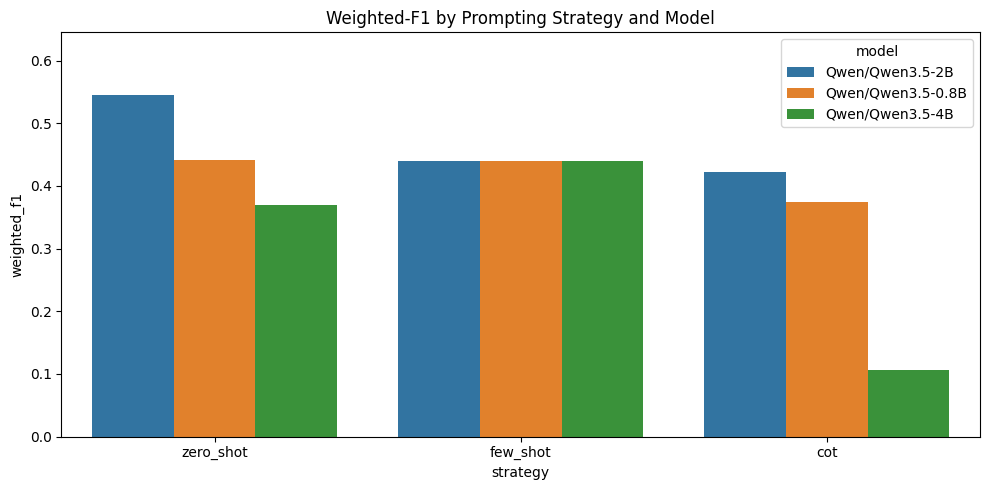

Saved: /kaggle/working/weighted_f1_by_strategy_model.png


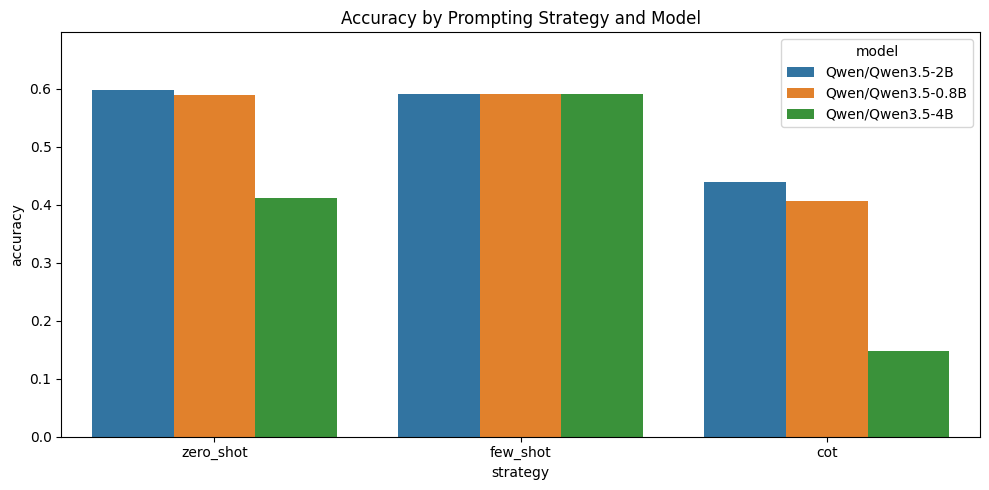

Saved: /kaggle/working/accuracy_by_strategy_model.png


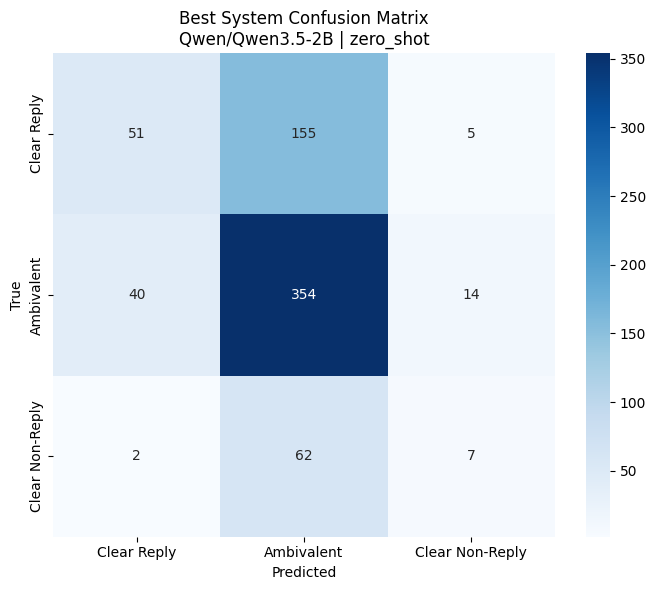

Saved: /kaggle/working/best_confusion_matrix.png


In [15]:
# Result plots
def save_barplot(metric: str, filename: str, title: str):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_df, x="strategy", y=metric, hue="model")
    plt.title(title)
    plt.ylim(0, max(0.01, min(1.0, results_df[metric].max() + 0.1)))
    plt.xticks(rotation=0)
    plt.tight_layout()
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

save_barplot("weighted_f1", "weighted_f1_by_strategy_model.png", "Weighted-F1 by Prompting Strategy and Model")
save_barplot("accuracy", "accuracy_by_strategy_model.png", "Accuracy by Prompting Strategy and Model")

cm = confusion_matrix(y_valid, best_pred_df["prediction"].tolist(), labels=LABELS)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Best System Confusion Matrix\n{BEST_MODEL_NAME} | {BEST_STRATEGY}")
plt.tight_layout()
path = OUTPUT_DIR / "best_confusion_matrix.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)

## 6. Subgroup analysis by question/answer length

,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,group_type,group,n
0,0.535865,0.492038,0.407184,0.392999,0.556435,0.535865,0.482904,question_len_group,short_q,237
1,0.611607,0.382524,0.366667,0.333549,0.530265,0.611607,0.525175,question_len_group,medium_q,224
2,0.646288,0.501555,0.442829,0.458613,0.615841,0.646288,0.623927,question_len_group,long_q,229
3,0.504348,0.498091,0.401372,0.384761,0.520849,0.504348,0.447299,answer_len_group,short_a,230
4,0.586957,0.340983,0.341851,0.298738,0.500268,0.586957,0.492328,answer_len_group,medium_a,230
5,0.700000,0.432821,0.426974,0.427788,0.672883,0.700000,0.683943,answer_len_group,long_a,230


Saved: /kaggle/working/subgroup_length_analysis.csv


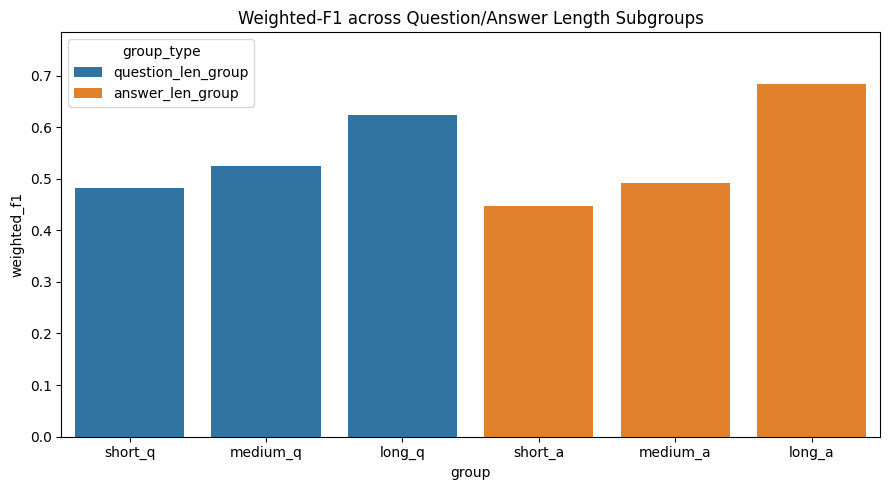

Saved: /kaggle/working/length_subgroup_weighted_f1.png


In [16]:
# Length subgroup analysis
analysis_df = valid_part.copy()
analysis_df["gold"] = y_valid
analysis_df["prediction"] = best_pred_df["prediction"].values
analysis_df["question_len"] = analysis_df["question"].str.split().str.len()
analysis_df["answer_len"] = analysis_df["answer"].str.split().str.len()

analysis_df["question_len_group"] = pd.qcut(analysis_df["question_len"], q=3, labels=["short_q", "medium_q", "long_q"], duplicates="drop")
analysis_df["answer_len_group"] = pd.qcut(analysis_df["answer_len"], q=3, labels=["short_a", "medium_a", "long_a"], duplicates="drop")

subgroup_rows = []
for group_col in ["question_len_group", "answer_len_group"]:
    for group_name, group_df in analysis_df.groupby(group_col, observed=False):
        if len(group_df) == 0:
            continue
        m = compute_metrics(group_df["gold"].tolist(), group_df["prediction"].tolist())
        m.update({"group_type": group_col, "group": str(group_name), "n": len(group_df)})
        subgroup_rows.append(m)

subgroup_df = pd.DataFrame(subgroup_rows)
display(subgroup_df)
subgroup_df.to_csv(OUTPUT_DIR / "subgroup_length_analysis.csv", index=False)
print("Saved:", OUTPUT_DIR / "subgroup_length_analysis.csv")

plt.figure(figsize=(9, 5))
sns.barplot(data=subgroup_df, x="group", y="weighted_f1", hue="group_type")
plt.title("Weighted-F1 across Question/Answer Length Subgroups")
plt.ylim(0, max(0.01, min(1.0, subgroup_df["weighted_f1"].max() + 0.1)))
plt.tight_layout()
path = OUTPUT_DIR / "length_subgroup_weighted_f1.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", path)

## 7. Error analysis

In [17]:
# Error analysis examples
errors_df = analysis_df[analysis_df["gold"] != analysis_df["prediction"]].copy()

# Keep concrete examples for the report.
error_examples = []
for gold_label in LABELS:
    part = errors_df[errors_df["gold"] == gold_label].head(8)
    error_examples.append(part)

error_examples_df = pd.concat(error_examples, ignore_index=True) if error_examples else pd.DataFrame()
display(error_examples_df[["id", "gold", "prediction", "question", "answer"]].head(20))

error_examples_df.to_csv(OUTPUT_DIR / "best_system_error_examples.csv", index=False)
print("Saved:", OUTPUT_DIR / "best_system_error_examples.csv")

print("Error counts by gold/prediction:")
display(pd.crosstab(errors_df["gold"], errors_df["prediction"]))

,id,gold,prediction,question,answer
0,2537,Clear Reply,Ambivalent,"Q. Thank you, Mr. President, Prime Minister.Mr...","With respect to Kashmir, obviously, this is a ..."
1,2518,Clear Reply,Ambivalent,Q. Where is your line in the sand?,"Well, look, I've got a whole bunch of lines in..."
2,920,Clear Reply,Ambivalent,"Q. But coming from you, it has more weight. Do...","I would think so, yes. I mean, I haven't spoke..."
3,420,Clear Reply,Ambivalent,"Q. Don't your officials vote by mail, sir? Peo...","They do, but that's different. That's called s..."
4,3189,Clear Reply,Ambivalent,"Q. Thank you, sir. Can you talk about your con...","Jennifer [Jennifer Loven, Associated Press], I..."
5,2875,Clear Reply,Ambivalent,"Q. Mr. President, you've expressed frustration...",Yes. I am—I believe that they're letting the A...
6,1432,Clear Reply,Ambivalent,"Q. Thank you, Mr. President. Two questions for...","It wouldn't bother me, other than the FBI, Jon..."
7,268,Clear Reply,Ambivalent,"Q. Okay. And then, a follow-up: You mentioned ...","Well, look, first of all, the significant reas..."
8,1456,Ambivalent,Clear Reply,"Q. President Putin, did you want President Tru...","Well, I guess I'll answer the first part of th..."
9,1412,Ambivalent,Clear Non-Reply,"Q. Mr. President, could I ask a question, sinc...",Since you're where? Since you're where?


Saved: /kaggle/working/best_system_error_examples.csv
Error counts by gold/prediction:


prediction,Ambivalent,Clear Non-Reply,Clear Reply
gold,,,
Ambivalent,0,14,40
Clear Non-Reply,62,0,2
Clear Reply,155,5,0


## 8. Final test-set submission

In [18]:
# Generate final predictions for the test set
print("Generating test predictions with best system:", BEST_MODEL_NAME, BEST_STRATEGY, INFERENCE_MODE)
clear_model_cache()

test_pred_df = generate_predictions(test_df, BEST_MODEL_NAME, BEST_STRATEGY, batch_size=BATCH_SIZE, few_shot_examples=FEW_SHOT_EXAMPLES, inference_mode=INFERENCE_MODE)

clear_model_cache()

display(test_pred_df.head())
print("Test prediction distribution:")
display(test_pred_df["prediction"].value_counts())

Generating test predictions with best system: Qwen/Qwen3.5-2B zero_shot generate

Loading Qwen/Qwen3.5-2B


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Qwen/Qwen3.5-2B | zero_shot | generate:   0%|          | 0/39 [00:00<?, ?it/s]

Finished 308 examples in 10.10 min


,id,question,answer,response,prediction
0,0,"Q. What about the redline, sir?","Well, the world has made it clear that these t...",Ambivalent,Ambivalent
1,1,Q. Will you invite them to the White House to ...,I think that anytime and anyplace that they ar...,Ambivalent,Ambivalent
2,2,"Q. Harsh. Mr. President, Japan has dropped the...",I think that the purpose of the U.N. Security ...,Ambivalent,Ambivalent
3,3,Q. The Lebanese Prime Minister is demanding a ...,I'll let Condi talk about the details of what ...,Ambivalent,Ambivalent
4,4,"Q. Thank you, Mr. President. Back on Iraq, a g...","No, I don't consider it a credible report; nei...",Ambivalent,Ambivalent


Test prediction distribution:


prediction
Ambivalent         250
Clear Reply         47
Clear Non-Reply     11
Name: count, dtype: int64

In [19]:
# Create Kaggle submission file
submission = pd.DataFrame()

if sample_submission is not None:
    submission = sample_submission.copy()
    id_col = submission.columns[0]
    pred_col = submission.columns[1]

    # Preserve sample_submission order if IDs match.
    pred_map = dict(zip(test_pred_df["id"], test_pred_df["prediction"]))
    if set(submission[id_col]).issubset(set(pred_map.keys())):
        submission[pred_col] = submission[id_col].map(pred_map)
    else:
        submission[pred_col] = test_pred_df["prediction"].values[:len(submission)]
else:
    submission["Id"] = test_pred_df["id"]
    submission["label"] = test_pred_df["prediction"]

submission_path = OUTPUT_DIR / "submission_best_prompting_system.csv"
submission.to_csv(submission_path, index=False)

display(submission.head())
print("Saved:", submission_path)

,Id,label
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent
3,3,Ambivalent
4,4,Ambivalent


Saved: /kaggle/working/submission_best_prompting_system.csv


## 10. Save prompting-system metadata and zip outputs

In [20]:
# Save best prompting system metadata
SAVE_DIR = OUTPUT_DIR / "saved_prompting_system"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

best_system_info = {
    "best_model_name": BEST_MODEL_NAME,
    "best_strategy": BEST_STRATEGY,
    "inference_mode": INFERENCE_MODE,
    "best_validation_metrics": best_row.to_dict(),
    "labels": LABELS,
    "base_system_prompt": BASE_SYSTEM_PROMPT,
    "max_input_tokens": MAX_INPUT_TOKENS,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "fast_debug": FAST_DEBUG,
    "note": "The Qwen model was not fine-tuned. This saves the best prompting configuration and experiment metadata.",
}

with open(SAVE_DIR / "best_prompting_system_config.json", "w", encoding="utf-8") as f:
    json.dump(best_system_info, f, indent=2, ensure_ascii=False)

with open(SAVE_DIR / "few_shot_examples.json", "w", encoding="utf-8") as f:
    json.dump(FEW_SHOT_EXAMPLES, f, indent=2, ensure_ascii=False)

with open(SAVE_DIR / "README_saved_prompting_system.txt", "w", encoding="utf-8") as f:
    f.write(f"""AI2 Homework 3 - Saved Prompting System

Best model:
{BEST_MODEL_NAME}

Best prompting strategy:
{BEST_STRATEGY}

Inference mode:
{INFERENCE_MODE}

""")

print("Saved prompting metadata to:", SAVE_DIR)
for p in SAVE_DIR.iterdir():
    print(" -", p.name)

Saved prompting metadata to: /kaggle/working/saved_prompting_system
 - best_prompting_system_config.json
 - few_shot_examples.json
 - README_saved_prompting_system.txt


In [21]:
# Zip all outputs
zip_base = str(OUTPUT_DIR / "ai2_hw3_outputs")

# Create a temporary folder containing only the important outputs.
package_dir = OUTPUT_DIR / "ai2_hw3_package"
if package_dir.exists():
    shutil.rmtree(package_dir)
package_dir.mkdir(parents=True, exist_ok=True)

important_files = [
    "validation_prompting_results.csv",
    "best_system_predictions.csv",
    "subgroup_length_analysis.csv",
    "best_system_error_examples.csv",
    "comparison_with_previous_assessments.csv",
    "submission_best_prompting_system.csv",
    "weighted_f1_by_strategy_model.png",
    "accuracy_by_strategy_model.png",
    "best_confusion_matrix.png",
    "length_subgroup_weighted_f1.png",
]

for fname in important_files:
    src = OUTPUT_DIR / fname
    if src.exists():
        shutil.copy2(src, package_dir / fname)
    else:
        print("Missing, not packaged:", fname)

shutil.copytree(SAVE_DIR, package_dir / "saved_prompting_system", dirs_exist_ok=True)

shutil.make_archive(base_name=zip_base, format="zip", root_dir=package_dir)
print("Created zip:", zip_base + ".zip")

Missing, not packaged: comparison_with_previous_assessments.csv
Created zip: /kaggle/working/ai2_hw3_outputs.zip
